# **California Housing Regression**

**Goal:** Compare 8+ neural network configurations across architectures, loss functions,
and optimizers to find the best regressor for California median house prices.

## 1. Imports

In [ ]:

import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau # Que hace esto?

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm 

# Reprocibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)

#Output folder for plots 
os.makedirs('Plots', exist_ok=True)
os.makedirs('Weights', exist_ok=True)


Device: cuda


## 2. Data Loading and Preprocessing

We will use a 70% of the data for training our models, 15% for validation and 15% for testing

In [2]:

# Load California housing dataset
data = fetch_california_housing()
X, y = data.data,  data.target.reshape(-1,1)

print(f'Dataset shape  : X_Shape: {X.shape},  y_Shape: {y.shape}')
print(f'Feature names  : {list(data.feature_names)}')
print(f'Target range   : [{y.min():.2f}, {y.max():.2f}] (median house value, $100k units)')

# train/test split
# First split off the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED)

# Then split the remaining data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED) 

print(f'\nSplit sizes: train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}')

# Feature scaling (standardization)
# Only fit the scalers on the training data to avoid data leakage, then transform all sets
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Cómo se ve esto? Qué es exactamente lo que se está haciendo? Y por qué es importante?
def make_loader(X_arr, y_arr, batch_size=64, shuffle=True):
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    y_t = torch.tensor(y_arr, dtype=torch.float32)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


Dataset shape  : (20640, 8)  ->  (20640, 1)
Feature names  : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range   : [0.15, 5.00] (median house value, $100k units)

Split sizes: train: 14448, val: 3096, test: 3096


## 3. Model architecture

In [8]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list, dropout_p: float = 0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout_p > 0.0:
                # Dropout randomly zeroes activations during training — helps generalisation
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        # Final linear layer → single output (regression)
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Test the model architecture
demo = RegressionNN(input_dim = 8, hidden_sizes=[64,32], dropout_p=0.2)
print(demo)
dummy = torch.randn(4, 8)
print('Output shape:', demo(dummy).shape)

RegressionNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Output shape: torch.Size([4, 1])


## 4. Experiment configuration

In [14]:
architectures = {
    "A":[16,8],  # 16 hidden units in the first layer, 8 in the second
    "B":[64], # 64 hidden units in the single hidden layer
    "C":[128,64,32]} # 128, 64, and 32 hidden units in each layer respectively (deeper and wider than A and B)

# ── Loss functions ────────────────────────────────────────────────────────────
# MSELoss : standard squared error, sensitive to outliers
# SmoothL1 : Huber-like, less sensitive to outliers than MSE
loss_funcs = {
    "MSE": nn.MSELoss,  
    "SmoothL1": nn.SmoothL1Loss}


optimizers = {
    "Adam": {'lr': 1e-3},  
    "SGD": {'lr': 1e-2}}   # Higher learning rate to compensate for lack of momentum

EPOCHS = 80 # Number of times to iterate over the entire training dataset
BATCH_SIZE = 64 # Number of samples per gradient update
WEIGHT_DECAY = 1e-4 # L2 regularization, prevents overfitting by penalizing large weights
DROPOUT_P = 0.0 # Could be added to test regularization effects

# LR scheduler patience: reduce LR if val loss doesn't improve for N epochs
SCHEDULER_PATIENCE = 10


## Training

In [ ]:
from copy import deepcopy


results    = []   # list of dicts — one per run
all_curves = {}   # {run_name: {'train': [...], 'val': [...]}}

for arch_name, hidden in architectures.items():
    for loss_name, LossClass in loss_funcs.items():
        for opt_name, opt_kwargs in optimizers.items():

            run_name = f'{arch_name}_{hidden}_loss{loss_name}_opt{opt_name}'
            print(f'\n▶  {run_name}')

            # DataLoaders 
            train_loader = make_loader(X_train_s, y_train_s, batch_size=BATCH_SIZE, shuffle=True)
            val_loader   = make_loader(X_val_s,   y_val_s,   batch_size=BATCH_SIZE, shuffle=False)
            test_loader  = make_loader(X_test_s,  y_test_s,  batch_size=BATCH_SIZE, shuffle=False)

            # Model, optimizer, scheduler
            torch.manual_seed(SEED)
            model     = RegressionNN(X_train_s.shape[1], hidden, dropout_p=DROPOUT_P).to(device)
            criterion = LossClass()

            if opt_name == 'Adam':
                optimizer = optim.Adam(model.parameters(), weight_decay=WEIGHT_DECAY, **opt_kwargs)
            else:
                optimizer = optim.SGD(model.parameters(), weight_decay=WEIGHT_DECAY, **opt_kwargs)

            # Reduce LR by factor 0.5 when val loss stops improving
            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                          patience=SCHEDULER_PATIENCE)

            train_losses, val_losses = [], []
            best_val_loss  = float('inf')
            best_weights   = None   # will hold state_dict of the best epoch

            # Epoch loop
            for ep in tqdm(range(EPOCHS), desc=run_name, leave=False):

                # Training pass 
                model.train()
                t_loss, t_n = 0.0, 0
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    optimizer.zero_grad()
                    loss = criterion(model(xb), yb)
                    loss.backward()
                    optimizer.step()
                    t_loss += loss.item() * xb.size(0)
                    t_n    += xb.size(0)

                # Validation pass (no gradient needed) 
                model.eval()
                v_loss, v_n = 0.0, 0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        v_loss += criterion(model(xb), yb).item() * xb.size(0)
                        v_n    += xb.size(0)

                avg_train = t_loss / t_n
                avg_val   = v_loss / v_n
                train_losses.append(avg_train)
                val_losses.append(avg_val)

                # Checkpoint: keep the weights that achieved the lowest val loss
                if avg_val < best_val_loss:
                    best_val_loss = avg_val
                    # deep-copy so further training doesn't overwrite this snapshot
                    best_weights  = deepcopy(model.state_dict())

                # Feed val loss to scheduler so it can reduce the LR if needed
                scheduler.step(avg_val)

            # Save best weights to disk 
            weight_path = os.path.join('Weights', f'{run_name}.pt')
            torch.save(best_weights, weight_path)

            # Evaluate on test set using the BEST checkpoint
            model.load_state_dict(best_weights)
            model.eval()
            preds_s, trues_s = [], []
            with torch.no_grad():
                for xb, yb in test_loader:
                    preds_s.append(model(xb.to(device)).cpu().numpy())
                    trues_s.append(yb.numpy())

            # Inverse-transform back to the original $100k unit scale
            preds = scaler_y.inverse_transform(np.vstack(preds_s))
            trues = scaler_y.inverse_transform(np.vstack(trues_s))

            mse = mean_squared_error(trues, preds)
            r2  = r2_score(trues, preds)
            print(f'   Test MSE={mse:.4f}  R²={r2:.4f}')

            results.append({
                'run':          run_name,
                'architecture': str(hidden),
                'loss_fn':      loss_name,
                'optimizer':    opt_name,
                'mse':          round(float(mse), 5),
                'r2':           round(float(r2),  5),
                'best_val_loss':round(float(best_val_loss), 6),
                'weight_file':  weight_path,
            })
            all_curves[run_name] = {'train': train_losses, 'val': val_losses}

            # Per-run loss curve (train + val) 
            plt.figure(figsize=(6, 3))
            plt.plot(train_losses, label='Train loss')
            plt.plot(val_losses,   label='Val loss',   linestyle='--')
            plt.title(f'Loss curves — {run_name}')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(os.path.join('Plots', f'{run_name}_loss.png'), dpi=100)
            plt.close()

print('\n All runs finished.')


▶  A_[16, 8]_lossMSE_optAdam


A_[16, 8]_lossMSE_optAdam:   0%|          | 0/80 [00:00<?, ?it/s]

   Test MSE=0.3056  R²=0.7668

▶  A_[16, 8]_lossMSE_optSGD


A_[16, 8]_lossMSE_optSGD:   0%|          | 0/80 [00:00<?, ?it/s]

   Test MSE=0.3347  R²=0.7446

▶  A_[16, 8]_lossSmoothL1_optAdam


...

   Test MSE=0.2867  R²=0.7812

▶  C_[128, 64, 32]_lossSmoothL1_optAdam


C_[128, 64, 32]_lossSmoothL1_optAdam:   0%|          | 0/80 [00:00<?, ?it/s]

   Test MSE=0.2536  R²=0.8065

▶  C_[128, 64, 32]_lossSmoothL1_optSGD


C_[128, 64, 32]_lossSmoothL1_optSGD:   0%|          | 0/80 [00:00<?, ?it/s]

   Test MSE=0.3219  R²=0.7543

 All runs finished.


## 6. Results summary

In [ ]:
# Build a DataFrame and sort by MSE (lower = better)
df = pd.DataFrame(results).sort_values('mse').reset_index(drop=True)

# Highlight the best (row 0) and worst (last row) for quick visual scanning
df.to_csv('Results_summary.csv', index=False)

# Styled display — only works in Jupyter; falls back gracefully elsewhere
def highlight_extremes(s):
    styles = [''] * len(s)
    styles[s.values.argmin()] = 'background-color: #d4edda'   # green = best
    styles[s.values.argmax()] = 'background-color: #f8d7da'   # red   = worst
    return styles

(
    df[['run', 'architecture', 'loss_fn', 'optimizer', 'mse', 'r2']]
    .style
    .apply(highlight_extremes, subset=['mse'])
    .format({'mse': '{:.5f}', 'r2': '{:.5f}'})
    .set_caption('Test-set metrics — sorted by MSE (↑ = worse)')
)

,run,architecture,loss_fn,optimizer,mse,r2
0,"C_[128, 64, 32]_lossSmoothL1_optAdam","[128, 64, 32]",SmoothL1,Adam,0.25361,0.80648
1,"C_[128, 64, 32]_lossMSE_optAdam","[128, 64, 32]",MSE,Adam,0.25525,0.80522
2,"C_[128, 64, 32]_lossMSE_optSGD","[128, 64, 32]",MSE,SGD,0.28673,0.78121
3,"A_[16, 8]_lossMSE_optAdam","[16, 8]",MSE,Adam,0.30557,0.76683
4,"A_[16, 8]_lossSmoothL1_optAdam","[16, 8]",SmoothL1,Adam,0.31033,0.76320
5,B_[64]_lossMSE_optAdam,[64],MSE,Adam,0.31139,0.76239
6,B_[64]_lossSmoothL1_optAdam,[64],SmoothL1,Adam,0.31748,0.75774
7,"C_[128, 64, 32]_lossSmoothL1_optSGD","[128, 64, 32]",SmoothL1,SGD,0.32195,0.75433
8,"A_[16, 8]_lossMSE_optSGD","[16, 8]",MSE,SGD,0.33469,0.74461
9,B_[64]_lossMSE_optSGD,[64],MSE,SGD,0.34409,0.73744


## 7. Bar charts: MSE and R2 Across Experiments

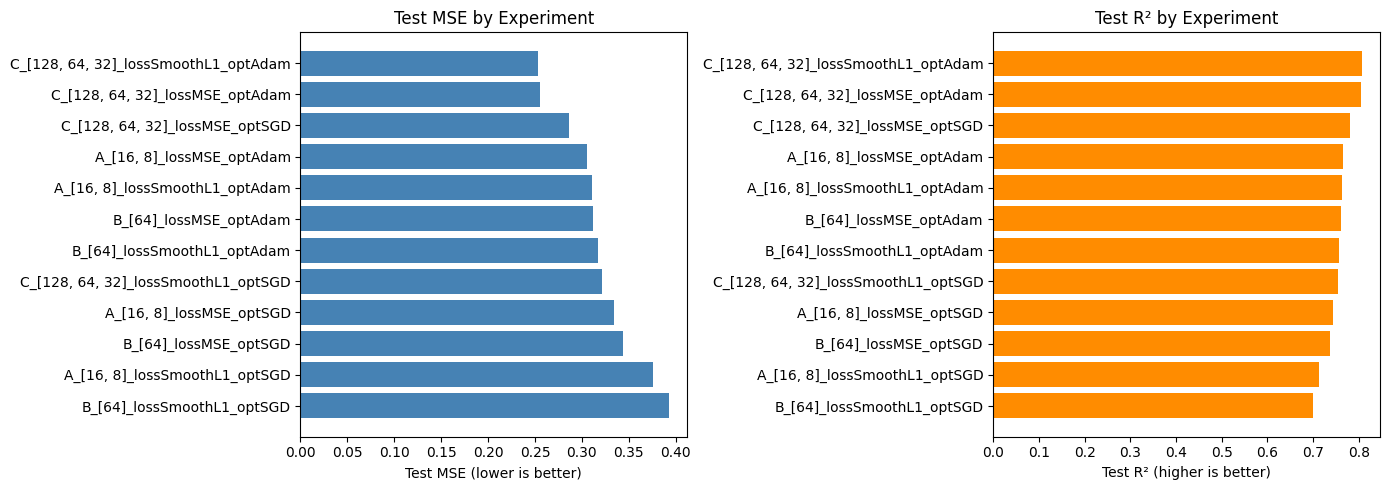

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MSE bar chart ---
axes[0].barh(df['run'], df['mse'], color='steelblue')
axes[0].set_xlabel('Test MSE (lower is better)')
axes[0].set_title('Test MSE by Experiment')
axes[0].invert_yaxis()   # best (lowest MSE) at the top

# --- R² bar chart ---
axes[1].barh(df['run'], df['r2'], color='darkorange')
axes[1].set_xlabel('Test R² (higher is better)')
axes[1].set_title('Test R² by Experiment')
axes[1].invert_yaxis()   # best (highest R²) at the top

plt.tight_layout()
plt.savefig('Plots/metrics_comparison.png', dpi=120)
plt.show()

## 8. Best Model: Prediction vs True + Residuals

Best run: C_[128, 64, 32]_lossSmoothL1_optAdam  |  MSE=0.25361  R²=0.80648


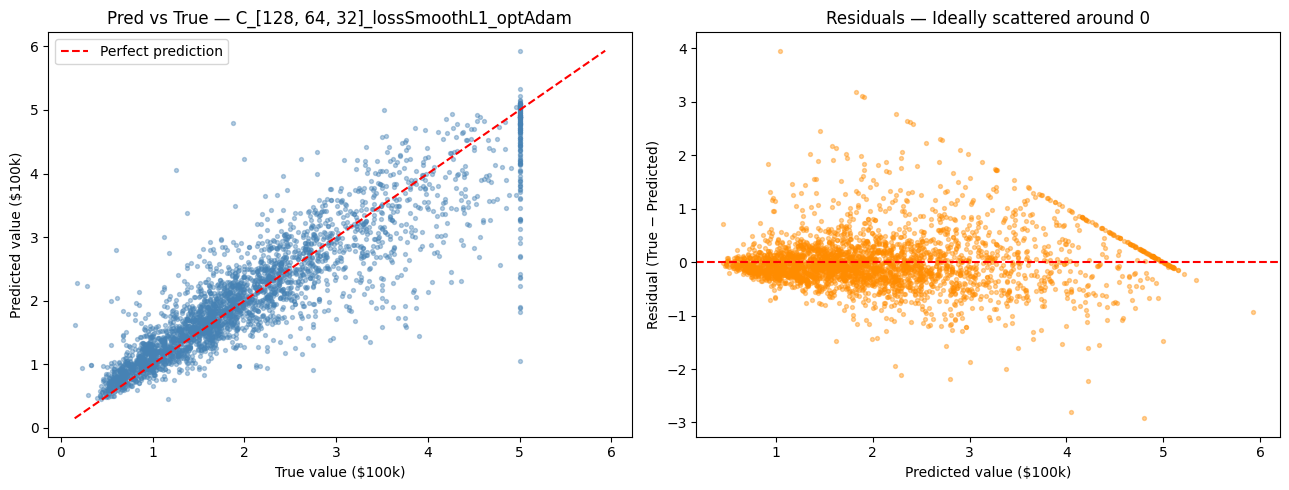

In [ ]:

# Retrieve the best run's metadata
best_row  = df.iloc[0]
best_run  = best_row['run']
print(f'Best run: {best_run}  |  MSE={best_row["mse"]:.5f}  R²={best_row["r2"]:.5f}')

import json
# Rebuild the model architecture and load the saved checkpoint
# Use json.loads instead of eval() — safe parsing of the stored list string
hidden    = json.loads(best_row['architecture'])
model_best = RegressionNN(X_test_s.shape[1], hidden, dropout_p=DROPOUT_P).to(device)
model_best.load_state_dict(torch.load(best_row['weight_file'], map_location=device))
model_best.eval()

# Generate predictions on the test set 
test_loader = make_loader(X_test_s, y_test_s, batch_size=BATCH_SIZE, shuffle=False)
preds_s, trues_s = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_s.append(model_best(xb.to(device)).cpu().numpy())
        trues_s.append(yb.numpy())

# Inverse-scale back to original units ($100k)
preds = scaler_y.inverse_transform(np.vstack(preds_s)).ravel()
trues = scaler_y.inverse_transform(np.vstack(trues_s)).ravel()
residuals = trues - preds

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pred vs True
axes[0].scatter(trues, preds, s=8, alpha=0.4, color='steelblue')
lo, hi = min(trues.min(), preds.min()), max(trues.max(), preds.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True value ($100k)')
axes[0].set_ylabel('Predicted value ($100k)')
axes[0].set_title(f'Pred vs True — {best_run}')
axes[0].legend()

# Residuals vs Predicted 
axes[1].scatter(preds, residuals, s=8, alpha=0.4, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted value ($100k)')
axes[1].set_ylabel('Residual (True − Predicted)')
axes[1].set_title('Residuals — Ideally scattered around 0')

plt.tight_layout()
plt.savefig('Plots/best_model_diagnostics.png', dpi=120)
plt.show()

## 9. Loss Curves

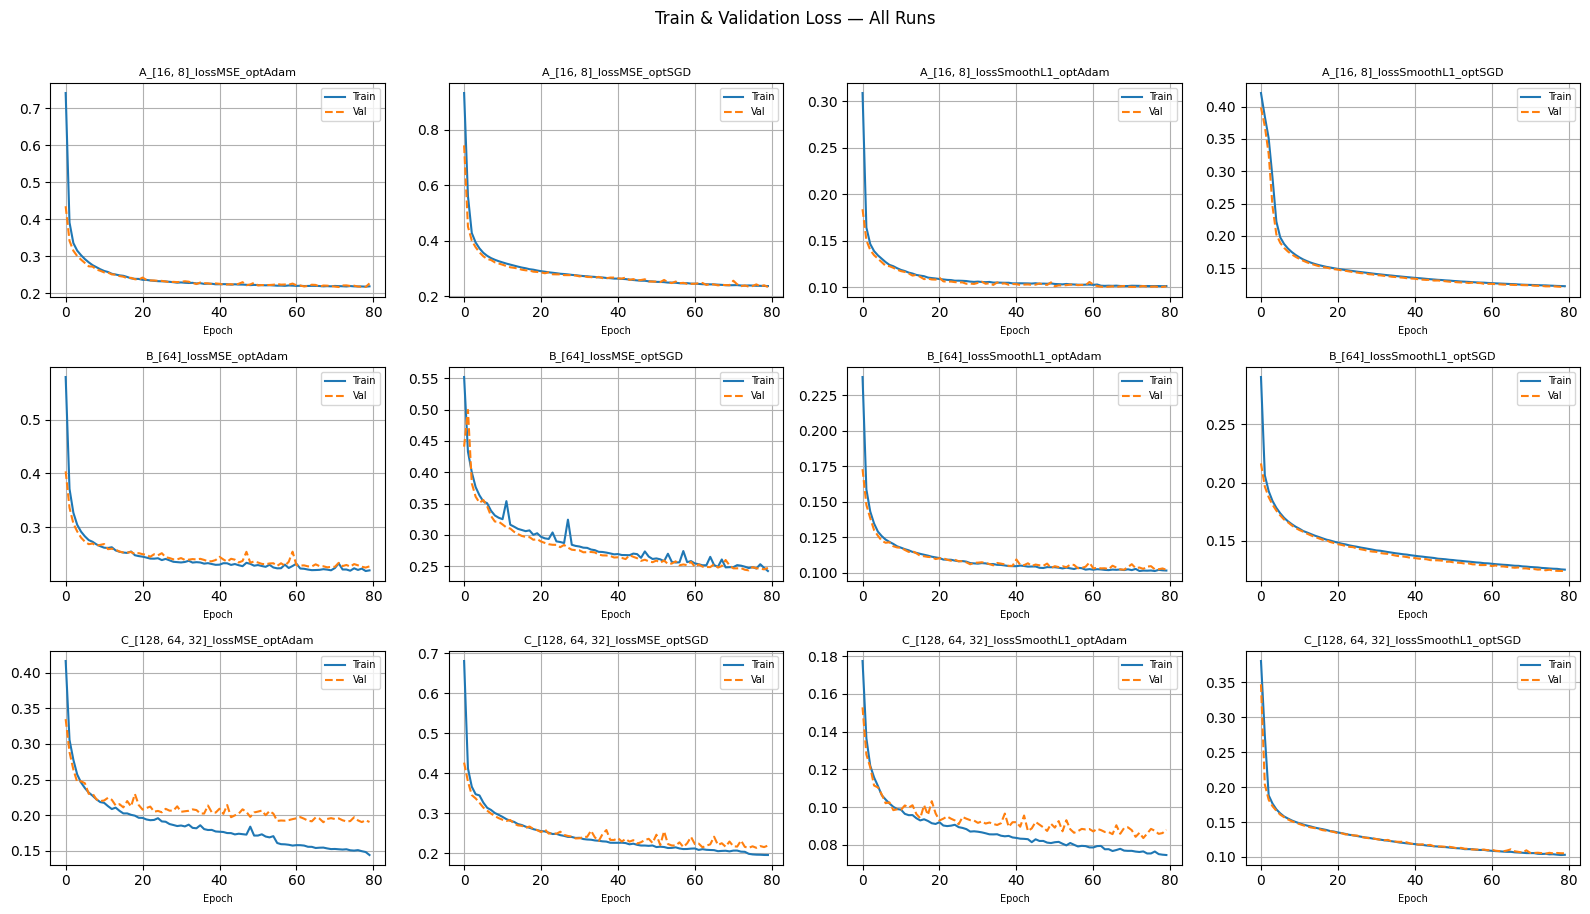

In [ ]:
# Retrieve the best run's metadata 
best_row  = df.iloc[0]
best_run  = best_row['run']
print(f'Best run: {best_run}  |  MSE={best_row["mse"]:.5f}  R²={best_row["r2"]:.5f}')

import json
# Rebuild the model architecture and load the saved checkpoint
# Use json.loads instead of eval() — safe parsing of the stored list string
hidden    = json.loads(best_row['architecture'])
model_best = RegressionNN(X_test_s.shape[1], hidden, dropout_p=DROPOUT_P).to(device)
model_best.load_state_dict(torch.load(best_row['weight_file'], map_location=device))
model_best.eval()

# Generate predictions on the test set
test_loader = make_loader(X_test_s, y_test_s, batch_size=BATCH_SIZE, shuffle=False)
preds_s, trues_s = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_s.append(model_best(xb.to(device)).cpu().numpy())
        trues_s.append(yb.numpy())

# Inverse-scale back to original units ($100k)
preds = scaler_y.inverse_transform(np.vstack(preds_s)).ravel()
trues = scaler_y.inverse_transform(np.vstack(trues_s)).ravel()
residuals = trues - preds

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pred vs True 
axes[0].scatter(trues, preds, s=8, alpha=0.4, color='steelblue')
lo, hi = min(trues.min(), preds.min()), max(trues.max(), preds.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True value ($100k)')
axes[0].set_ylabel('Predicted value ($100k)')
axes[0].set_title(f'Pred vs True — {best_run}')
axes[0].legend()

# Residuals vs Predicted 
axes[1].scatter(preds, residuals, s=8, alpha=0.4, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted value ($100k)')
axes[1].set_ylabel('Residual (True − Predicted)')
axes[1].set_title('Residuals — Ideally scattered around 0')

plt.tight_layout()
plt.savefig('Plots/best_model_diagnostics.png', dpi=120)
plt.show()

## 10. Conclusions

1. All configurations are stable and capable of learning meaningful patterns from the data.
2. SmoothL1 provides a slight but consistent improvement over MSE when paired with Adam in the best-performing architecture.
3. Adam consistently converges faster and more smoothly than SGD, making it a better default optimizer for this task.
4. A single-layer architecture lacks sufficient representational depth, while deeper architectures capture more complex patterns in the data.
5. Regularization and dataset simplicity prevent severe overfitting, even in deeper architectures.
6. Most learning occurs in the first 20–30 epochs, with diminishing returns afterward. This suggests that early stopping could reduce training time without sacrificing performance.

The deeper architecture [128, 64, 32] consistently outperformed both shallower alternatives, indicating that additional depth provides meaningful representational benefits for this dataset. Interestingly, the single-layer model [64] underperformed even the smaller two-layer network [16, 8], suggesting that depth, not just width, plays a critical role in capturing the underlying structure of the data.
